# 04 - Error Analysis

**Goal:** Understand *when* and *why* the model fails. 

## 1. Setup

In [21]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json

from evaluate import evaluate

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load Model and Generate Predictions

In [22]:
df = pd.read_csv('../data/features_dataset.csv', parse_dates=['time'])

with open('../data/best_xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/feature_columns.json', 'r') as f:
    feature_cols = json.load(f)

TARGET = 'total load actual'

# Same test split as notebook 03
split_date = df['time'].max() - pd.Timedelta(days=90)
test_df = df[df['time'] >= split_date].dropna(subset=feature_cols + [TARGET]).copy()

test_df['prediction'] = model.predict(test_df[feature_cols])
test_df['residual'] = test_df[TARGET] - test_df['prediction']
test_df['abs_error'] = test_df['residual'].abs()
test_df['pct_error'] = (test_df['residual'] / test_df[TARGET] * 100)

print(f'Test set: {len(test_df):,} rows')
evaluate(test_df[TARGET], test_df['prediction'], model_name='XGBoost on Test Set')

Test set: 2,161 rows

XGBoost on Test Set:
  MAE:  414.83
  RMSE: 634.62
  MAPE: 1.48%


{'model': 'XGBoost on Test Set',
 'MAE': 414.83,
 'RMSE': np.float64(634.62),
 'MAPE': np.float64(1.48)}

## 3. Residual Distribution

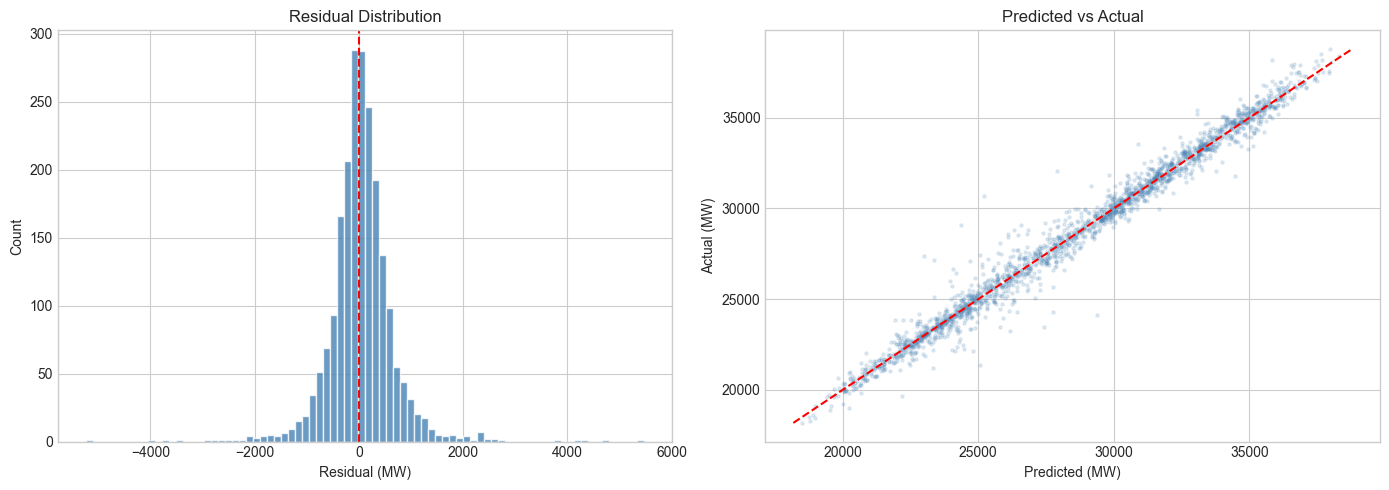

Mean residual (bias): 39.4 MW
Median residual:      24.6 MW


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(test_df['residual'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (MW)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution')

# Predicted vs actual
axes[1].scatter(test_df['prediction'], test_df[TARGET], alpha=0.15, s=5, color='steelblue')
min_val = min(test_df['prediction'].min(), test_df[TARGET].min())
max_val = max(test_df['prediction'].max(), test_df[TARGET].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[1].set_xlabel('Predicted (MW)')
axes[1].set_ylabel('Actual (MW)')
axes[1].set_title('Predicted vs Actual')

plt.tight_layout()
plt.show()

print(f'Mean residual (bias): {test_df["residual"].mean():.1f} MW')
print(f'Median residual:      {test_df["residual"].median():.1f} MW')

## 4. Error by Hour of Day

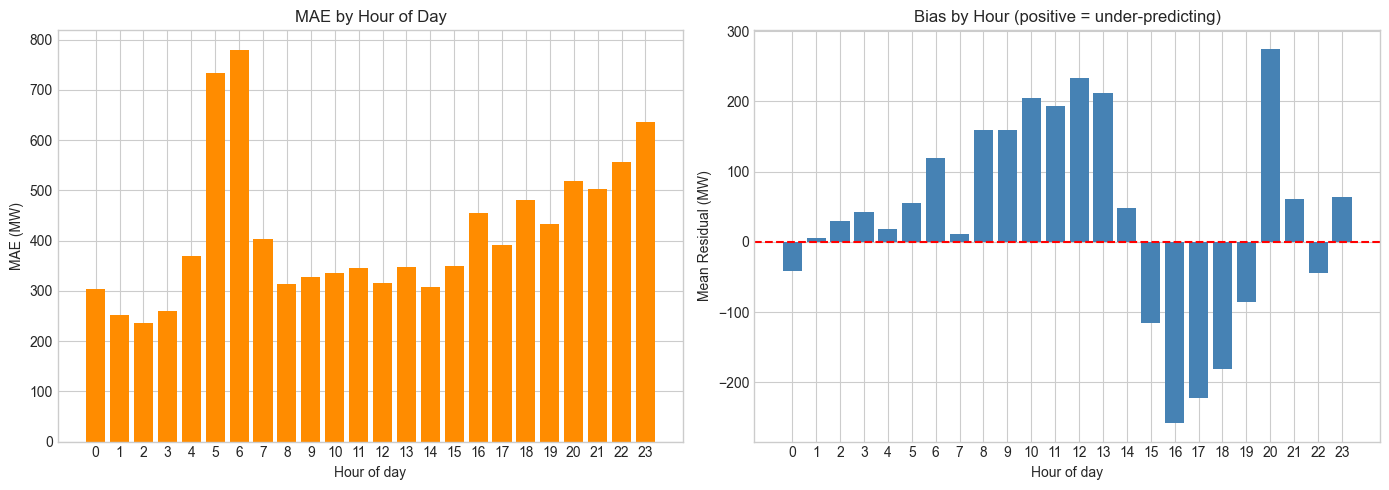

Hours with highest MAE:
        MAE  Mean_Residual  Std_Residual
hour                                    
6     779.4          120.1        1229.3
5     734.4           55.3        1191.8
23    635.8           63.5         998.4
22    555.9          -44.4         880.0
20    518.5          274.5         648.0


In [24]:
hourly_error = test_df.groupby('hour').agg(
    MAE=('abs_error', 'mean'),
    Mean_Residual=('residual', 'mean'),
    Std_Residual=('residual', 'std'),
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_error.index, hourly_error['MAE'], color='darkorange')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('MAE by Hour of Day')
axes[0].set_xticks(range(0, 24))

axes[1].bar(hourly_error.index, hourly_error['Mean_Residual'], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean Residual (MW)')
axes[1].set_title('Bias by Hour (positive = under-predicting)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print('Hours with highest MAE:')
print(hourly_error.nlargest(5, 'MAE'))

## 5. Error by Day of Week

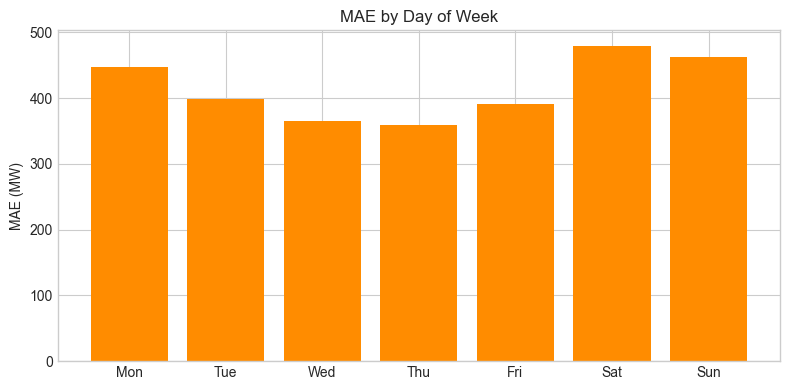

Weekday MAE: 392.1 MW
Weekend MAE: 470.9 MW


In [25]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

daily_error = test_df.groupby('dayofweek').agg(
    MAE=('abs_error', 'mean'),
    Mean_Residual=('residual', 'mean'),
).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(7), daily_error['MAE'], color='darkorange', tick_label=day_names)
ax.set_ylabel('MAE (MW)')
ax.set_title('MAE by Day of Week')
plt.tight_layout()
plt.show()

print(f'Weekday MAE: {test_df[test_df["is_weekend"]==0]["abs_error"].mean():.1f} MW')
print(f'Weekend MAE: {test_df[test_df["is_weekend"]==1]["abs_error"].mean():.1f} MW')

## 6. Error by Month

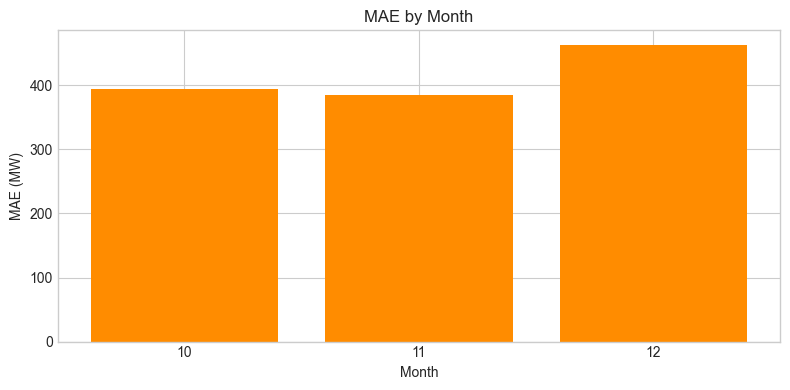

         MAE  Mean_Residual  Count
month                             
10     394.6           61.9    698
11     385.1            0.6    720
12     462.7           55.8    743


In [26]:
monthly_error = test_df.groupby('month').agg(
    MAE=('abs_error', 'mean'),
    Mean_Residual=('residual', 'mean'),
    Count=('abs_error', 'count'),
).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_error.index, monthly_error['MAE'], color='darkorange')
ax.set_xlabel('Month')
ax.set_ylabel('MAE (MW)')
ax.set_title('MAE by Month')
ax.set_xticks(monthly_error.index)
plt.tight_layout()
plt.show()

print(monthly_error)

## 7. Error vs Temperature

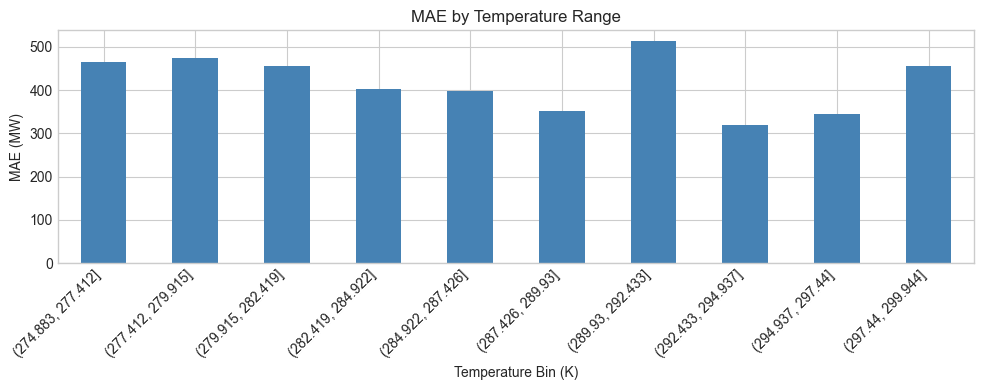

                      MAE  Count
temp_bin                        
(274.883, 277.412]  464.3     36
(277.412, 279.915]  474.0    192
(279.915, 282.419]  456.9    305
(282.419, 284.922]  403.7    425
(284.922, 287.426]  398.3    480
(287.426, 289.93]   352.0    341
(289.93, 292.433]   512.7    199
(292.433, 294.937]  318.7    100
(294.937, 297.44]   344.1     46
(297.44, 299.944]   456.0     37


In [27]:
if 'temp_mean' in test_df.columns:
    test_df['temp_bin'] = pd.cut(test_df['temp_mean'], bins=10)

    temp_error = test_df.groupby('temp_bin', observed=True).agg(
        MAE=('abs_error', 'mean'),
        Count=('abs_error', 'count'),
    ).round(1)

    fig, ax = plt.subplots(figsize=(10, 4))
    temp_error['MAE'].plot.bar(ax=ax, color='steelblue')
    ax.set_xlabel('Temperature Bin (K)')
    ax.set_ylabel('MAE (MW)')
    ax.set_title('MAE by Temperature Range')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(temp_error)
else:
    print('temp_mean not found — check feature engineering notebook.')

## 8. Worst Predictions

In [28]:
worst = test_df.nlargest(20, 'abs_error')[[
    'time', TARGET, 'prediction', 'residual', 'abs_error',
    'hour', 'dayofweek', 'is_weekend', 'month'
]]

print('=== 20 Worst Predictions ===')
print(worst.to_string(index=False))

print(f'\nDate range of worst errors: {worst["time"].min()} → {worst["time"].max()}')
print(f'Weekend proportion: {worst["is_weekend"].mean():.0%}')
print(f'Most common hour: {worst["hour"].mode().values}')
print(f'Most common day: {worst["dayofweek"].mode().values}')

=== 20 Worst Predictions ===
               time  total load actual   prediction     residual   abs_error  hour  dayofweek  is_weekend  month
2018-10-12 05:00:00            30672.0 25197.150391  5474.849609 5474.849609     5          4           0     10
2018-11-02 06:00:00            24138.0 29380.492188 -5242.492188 5242.492188     6          4           0     11
2018-10-06 22:00:00            29100.0 24349.585938  4750.414062 4750.414062    22          5           1     10
2018-10-06 23:00:00            27374.0 22992.634766  4381.365234 4381.365234    23          5           1     10
2018-12-02 06:00:00            32070.0 27913.716797  4156.283203 4156.283203     6          6           1     12
2018-11-08 06:00:00            23474.0 27425.007812 -3951.007812 3951.007812     6          3           0     11
2018-10-09 05:00:00            27157.0 23358.099609  3798.900391 3798.900391     5          1           0     10
2018-12-10 05:00:00            21380.0 25073.798828 -3693.798828 36

## 9. Time Series of Errors

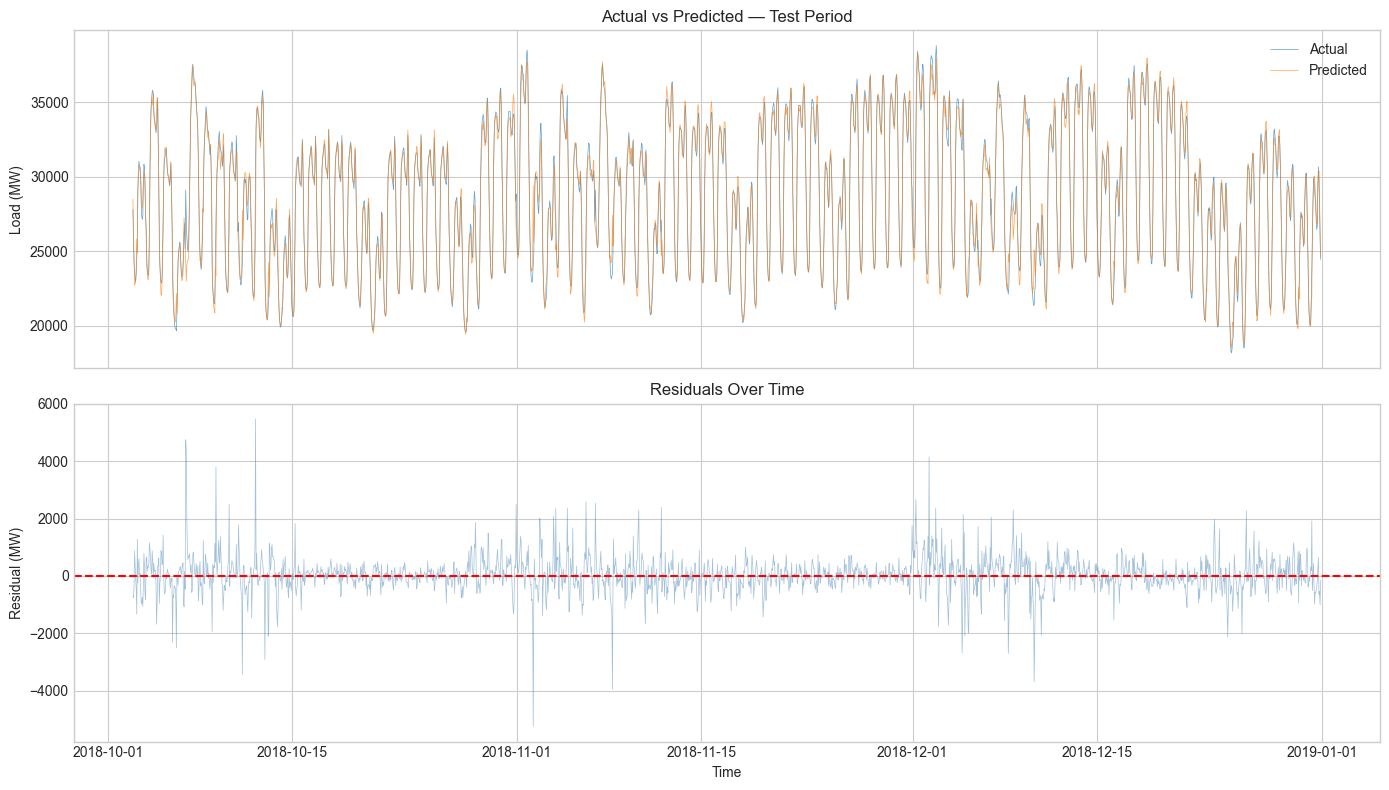

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Actual vs predicted
axes[0].plot(test_df['time'], test_df[TARGET], alpha=0.7, linewidth=0.5, label='Actual')
axes[0].plot(test_df['time'], test_df['prediction'], alpha=0.7, linewidth=0.5, label='Predicted')
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('Actual vs Predicted — Test Period')
axes[0].legend()

# Residuals
axes[1].plot(test_df['time'], test_df['residual'], alpha=0.5, linewidth=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_ylabel('Residual (MW)')
axes[1].set_xlabel('Time')
axes[1].set_title('Residuals Over Time')

plt.tight_layout()
plt.show()

## 10. Residual Autocorrelation

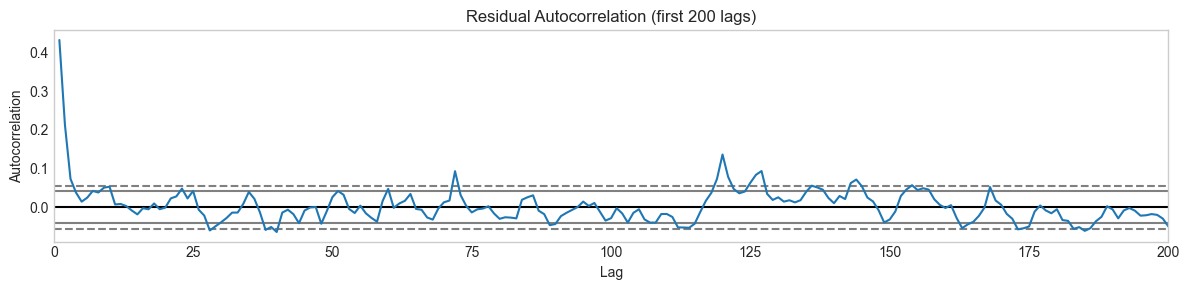

Autocorrelation at lag 1h: 0.432
Autocorrelation at lag 24h: 0.023
Autocorrelation at lag 168h: 0.058


In [30]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 3))
autocorrelation_plot(test_df['residual'].values, ax=ax)
ax.set_xlim(0, 200)
ax.set_title('Residual Autocorrelation (first 200 lags)')
plt.tight_layout()
plt.show()

residuals = test_df['residual'].values
for lag in [1, 24, 168]:
    corr = np.corrcoef(residuals[lag:], residuals[:-lag])[0, 1]
    print(f'Autocorrelation at lag {lag}h: {corr:.3f}')